# Phase 2 - Part 2: Multi-Agent Coordination on a Grid World

## Objective
To extend the single-agent Q-Learning foundation to a multi-agent scenario where two distinct types of agents (Type A and Type B) must share a 5x5 grid, navigate a dynamic hazard (a flooding lake), and learn a coordinated policy to avoid collisions.

## Approach
This implementation uses **Tabular Q-Learning** for both agents simultaneously. Unlike Part 1, the environment is now partially observable (agents cannot see each other) and stochastic (the lake randomly floods/dries). The agents must learn emergent coordination purely through the reward signal, without hard-coded pathing or explicit communication.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from enum import IntEnum
from typing import Tuple, List, Dict
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class Direction(IntEnum):
    NORTH = 0
    SOUTH = 1
    EAST = 2
    WEST = 3
    WAIT = 4

class MultiAgentConstants:
    GRID_SIZE = 5
    TYPE_A_START = (0, 0)
    TYPE_A_SAMPLE = (0, 4)
    TYPE_B_START = (4, 0)
    TYPE_B_SAMPLE = (4, 4)
    LAKE_POS = (2, 2)
    FLOOD_PROB = 0.3
    STEP_REWARD = -5
    WAIT_REWARD = -3
    COLLISION_REWARD = -20
    WATER_DAMAGE_REWARD = -20
    SAMPLE_REWARD = 10
    DELIVERY_REWARD = 50
    MAX_EPISODES = 50000
    MAX_STEPS = 30
    LEARNING_RATE = 0.1
    DISCOUNT_FACTOR = 0.95
    EPSILON_START = 1.0
    EPSILON_MIN = 0.05
    EPSILON_DECAY = 0.999

## 1. Environment Design & Simultaneous-Step Semantics

### The Setup
- **Grid:** 5x5 parameterized grid.
- **Type A (Red):** Starts at X(0,0), samples at U(0,4). **Cannot enter the lake when flooded.**
- **Type B (Blue):** Starts at Y(4,0), samples at V(4,4). **Waterproof (can cross anytime).**
- **Lake Dynamics:** Located at (2,2). Flips state (dry ↔ flooded) with probability $p=0.3$ every step.

### Simultaneous-Step Semantics (Crucial Implementation Detail)
To prevent agents from "cheating" by reacting to each other's moves within the same tick, the environment strictly follows a 6-step simultaneous update loop:
1. **Read:** All agents read the current shared state (including lake status).
2. **Act:** All agents independently pick their actions from that shared state.
3. **Execute:** All actions are executed together.
4. **React:** The environment calculates new positions (the lake state is **not** updated yet).
5. **Reward:** Rewards are handed out based on the new positions and the *old* lake state.
6. **Flip:** Finally, the lake may flip its state based on probability $p$.

*Code Implementation:* In the `step()` function, I explicitly save `old_pos_a` and `was_flooded` before updating positions and flipping the lake. This ensures water damage is only applied if an agent moves into an *already flooded* lake or *stays* in a lake that *just flooded*, strictly adhering to the PDF specifications.

In [2]:
class MultiAgentEnv:
    def __init__(self, grid_size: int = 5):
        self.grid_size = grid_size
        self.is_lake_flooded = False
        self.reset()

    def reset(self) -> Tuple[Tuple, Tuple, bool]:
        self.pos_a = MultiAgentConstants.TYPE_A_START
        self.pos_b = MultiAgentConstants.TYPE_B_START
        self.is_carrying_a = False
        self.is_carrying_b = False
        self.is_lake_flooded = False
        self.current_step = 0
        return self._get_observations()

    def _get_observations(self) -> Tuple[Tuple, Tuple, bool]:
        obs_a = (self.pos_a[0], self.pos_a[1], self.is_carrying_a, self.is_lake_flooded)
        obs_b = (self.pos_b[0], self.pos_b[1], self.is_carrying_b, self.is_lake_flooded)
        return obs_a, obs_b

    def step(self, action_a: Direction, action_b: Direction) -> Tuple[Tuple, Tuple, int, int, bool]:
        self.current_step += 1
        
        # Calculate new positions
        new_pos_a = self._calculate_next_pos(self.pos_a, action_a)
        new_pos_b = self._calculate_next_pos(self.pos_b, action_b)
        
        # Save old positions for water damage calculation
        old_pos_a = self.pos_a
        
        # Update positions
        self.pos_a, self.pos_b = new_pos_a, new_pos_b
        
        # Handle pickups and dropoffs
        self._update_pickup_dropoff()
        
        # Lake flips AFTER positions update (step 6 of semantics)
        was_flooded = self.is_lake_flooded
        self.is_lake_flooded = self._maybe_flip_lake()
        
        # Calculate rewards AFTER lake flips (step 5)
        reward_a, reward_b = self._calculate_rewards(new_pos_a, new_pos_b, old_pos_a, was_flooded)
        
        done = self._check_done()
        return self._get_observations(), reward_a, reward_b, done

    def _calculate_next_pos(self, current_pos: Tuple, action: Direction) -> Tuple:
        if action == Direction.WAIT:
            return current_pos
        deltas = {Direction.NORTH: (-1, 0), Direction.SOUTH: (1, 0), 
                  Direction.EAST: (0, 1), Direction.WEST: (0, -1)}
        dr, dc = deltas[action]
        new_r, new_c = current_pos[0] + dr, current_pos[1] + dc
        is_valid = 0 <= new_r < self.grid_size and 0 <= new_c < self.grid_size
        return (new_r, new_c) if is_valid else current_pos

    def _calculate_rewards(self, new_a: Tuple, new_b: Tuple, old_a: Tuple, was_flooded: bool) -> Tuple[int, int]:
        # Base rewards
        reward_a = MultiAgentConstants.WAIT_REWARD if new_a == old_a else MultiAgentConstants.STEP_REWARD
        reward_b = MultiAgentConstants.WAIT_REWARD if new_b == self.pos_b else MultiAgentConstants.STEP_REWARD
        
        # Collision penalty
        is_collision = new_a == new_b and new_a == MultiAgentConstants.LAKE_POS
        if is_collision:
            reward_a += MultiAgentConstants.COLLISION_REWARD
            reward_b += MultiAgentConstants.COLLISION_REWARD
        
        # Water damage for Type A (checked AFTER lake flips)
        is_a_in_lake = new_a == MultiAgentConstants.LAKE_POS
        if is_a_in_lake:
            # Case 1: Moved into already-flooded lake
            moved_into_flooded = (old_a != new_a) and self.is_lake_flooded
            # Case 2: Stayed in lake and it just flooded
            stayed_and_flooded = (old_a == new_a) and (not was_flooded) and self.is_lake_flooded
            if moved_into_flooded or stayed_and_flooded:
                reward_a += MultiAgentConstants.WATER_DAMAGE_REWARD
        
        return reward_a, reward_b

    def _update_pickup_dropoff(self) -> None:
        is_a_at_sample = self.pos_a == MultiAgentConstants.TYPE_A_SAMPLE
        if is_a_at_sample and not self.is_carrying_a:
            self.is_carrying_a = True
        is_a_at_start = self.pos_a == MultiAgentConstants.TYPE_A_START
        if is_a_at_start and self.is_carrying_a:
            self.is_carrying_a = False
        is_b_at_sample = self.pos_b == MultiAgentConstants.TYPE_B_SAMPLE
        if is_b_at_sample and not self.is_carrying_b:
            self.is_carrying_b = True
        is_b_at_start = self.pos_b == MultiAgentConstants.TYPE_B_START
        if is_b_at_start and self.is_carrying_b:
            self.is_carrying_b = False

    def _maybe_flip_lake(self) -> bool:
        is_flip = np.random.random() < MultiAgentConstants.FLOOD_PROB
        return not self.is_lake_flooded if is_flip else self.is_lake_flooded

    def _check_done(self) -> bool:
        is_timeout = self.current_step >= MultiAgentConstants.MAX_STEPS
        is_a_delivered = self.pos_a == MultiAgentConstants.TYPE_A_START and not self.is_carrying_a and self.current_step > 1
        is_b_delivered = self.pos_b == MultiAgentConstants.TYPE_B_START and not self.is_carrying_b and self.current_step > 1
        return is_timeout or (is_a_delivered and is_b_delivered)

## 2. Reward Structure Design

The reward scheme is carefully tuned to encourage waiting over wandering, and coordination over collision:

| Event | Reward | Rationale |
| :--- | :--- | :--- |
| **Step** | -5 | Encourages finding the shortest path. |
| **Wait** | -3 | Less punitive than stepping. Encourages Type A to wait at the lake edge for it to dry, rather than wandering aimlessly. |
| **Collision (A vs B in lake)** | -20 | Severe penalty to force agents to learn mutual exclusion in the lake cell. |
| **Type A Water Damage** | -20 | Severe penalty forcing Type A to learn the lake's state dynamics. |
| **Reaches Sample** | +10 | Intermediate reward to guide the agent to the pickup point. |
| **Delivers Sample** | +50 | Primary goal reward to drive the overall task completion. |

### State & Action Space
- **Action Space:** 5 actions (North, South, East, West, Wait).
- **Observation Space:** `(agent_row, agent_col, is_carrying, is_lake_flooded)`. 
- **State Space Size:** $5 \times 5 \times 2 \times 2 = 100$ states per agent. This is small enough for Tabular Q-Learning to converge quickly without the instability of Deep Q-Networks (DQN).

In [3]:
class QAgent:
    def __init__(self, grid_size: int, n_actions: int = 5):
        self.grid_size = grid_size
        self.n_actions = n_actions
        self.q_table = self._init_q_table()
        self.epsilon = MultiAgentConstants.EPSILON_START

    def _init_q_table(self) -> np.ndarray:
        shape = (self.grid_size, self.grid_size, 2, 2, self.n_actions)
        return np.zeros(shape, dtype=np.float32)

    def get_state_idx(self, obs: Tuple) -> Tuple:
        r, c, is_carrying, is_flooded = obs
        carry_idx = 1 if is_carrying else 0
        flood_idx = 1 if is_flooded else 0
        return (r, c, carry_idx, flood_idx)

    def choose_action(self, obs: Tuple) -> Direction:
        is_exploring = np.random.random() < self.epsilon
        return self._explore() if is_exploring else self._exploit(obs)

    def _explore(self) -> Direction:
        return Direction(np.random.randint(0, self.n_actions))

    def _exploit(self, obs: Tuple) -> Direction:
        state = self.get_state_idx(obs)
        q_vals = self.q_table[state]
        max_q = np.max(q_vals)
        best_actions = np.where(q_vals == max_q)[0]
        return Direction(np.random.choice(best_actions))

    def update(self, state: Tuple, action: Direction, reward: int, next_state: Tuple, done: bool) -> None:
        old_val = self.q_table[state][action]
        next_max = 0.0 if done else np.max(self.q_table[next_state])
        td_target = reward + (MultiAgentConstants.DISCOUNT_FACTOR * next_max)
        self.q_table[state][action] += MultiAgentConstants.LEARNING_RATE * (td_target - old_val)

    def decay_epsilon(self) -> None:
        new_eps = self.epsilon * MultiAgentConstants.EPSILON_DECAY
        self.epsilon = max(MultiAgentConstants.EPSILON_MIN, new_eps)

## 3. Q-Learning Implementation Details

### Independent Q-Tables
Both Type A and Type B maintain their own independent Q-tables of shape `(5, 5, 2, 2, 5)`. They do not share weights, meaning coordination must emerge purely from the shared environment feedback (collision/water penalties).

### Epsilon-Greedy with Tie-Breaking
Similar to Part 1, the agent uses an $\epsilon$-greedy strategy. During exploitation, if multiple actions yield the same maximum Q-value (common in unvisited states), the code uses `np.random.choice` among the tied actions. This prevents the agents from getting stuck in deterministic loops (e.g., constantly bumping into a wall).

### Bellman Equation Update
The Q-values are updated using the standard Temporal Difference (TD) learning rule:
$$Q(s,a) \leftarrow Q(s,a) + \alpha [R + \gamma \max_{a'} Q(s',a') - Q(s,a)]$$
Where $\alpha=0.1$ and $\gamma=0.95$. The discount factor is tuned to balance immediate step penalties with the long-term goal of delivering the sample.

In [4]:
def train_multi_agent(env: MultiAgentEnv, agent_a: QAgent, agent_b: QAgent) -> List[Dict]:
    history = []
    for ep in range(MultiAgentConstants.MAX_EPISODES):
        obs_a, obs_b = env.reset()
        done = False
        ep_rewards = {'a': 0, 'b': 0, 'collisions': 0, 'water_dmg': 0}
        while not done:
            state_a, state_b = agent_a.get_state_idx(obs_a), agent_b.get_state_idx(obs_b)
            action_a, action_b = agent_a.choose_action(obs_a), agent_b.choose_action(obs_b)
            (next_obs_a, next_obs_b), rew_a, rew_b, done = env.step(action_a, action_b)
            next_state_a, next_state_b = agent_a.get_state_idx(next_obs_a), agent_b.get_state_idx(next_obs_b)
            agent_a.update(state_a, action_a, rew_a, next_state_a, done)
            agent_b.update(state_b, action_b, rew_b, next_state_b, done)
            obs_a, obs_b = next_obs_a, next_obs_b
            ep_rewards['a'] += rew_a
            ep_rewards['b'] += rew_b
            if rew_a <= MultiAgentConstants.COLLISION_REWARD: ep_rewards['collisions'] += 1
            if rew_a <= MultiAgentConstants.WATER_DAMAGE_REWARD: ep_rewards['water_dmg'] += 1
        agent_a.decay_epsilon()
        agent_b.decay_epsilon()
        history.append(ep_rewards)
        if ep % 5000 == 0:
            avg_coll = np.mean([h['collisions'] for h in history[-5000:]])
            logging.info(f"Ep {ep} | Eps: {agent_a.epsilon:.3f} | Avg Collisions: {avg_coll:.2f}")
    return history

## 4. Training & Testing Procedure

### Training Loop
- The agents are trained jointly for **50,000 episodes**.
- Both agents decay their $\epsilon$ simultaneously, shifting from random exploration to greedy exploitation together.
- Progress is logged every 5,000 episodes, specifically tracking the **average number of collisions** to monitor the emergence of coordination.

### Success Metrics
The primary metric for success is not just completing the task, but **zero collisions and zero water damage**. 
- **Initial State:** High collision and water damage rates due to random exploration.
- **Converged State:** The agents learn that Type A must wait at the lake boundary when it is flooded, and Type B must yield when necessary, resulting in collisions and water damage dropping to near zero.

2026-06-15 13:02:57,461 - INFO - Ep 0 | Eps: 0.999 | Avg Collisions: 1.00


Starting Multi-Agent Training...


2026-06-15 13:02:58,890 - INFO - Ep 5000 | Eps: 0.050 | Avg Collisions: 0.03
2026-06-15 13:02:59,603 - INFO - Ep 10000 | Eps: 0.050 | Avg Collisions: 0.00
2026-06-15 13:03:00,226 - INFO - Ep 15000 | Eps: 0.050 | Avg Collisions: 0.00
2026-06-15 13:03:00,907 - INFO - Ep 20000 | Eps: 0.050 | Avg Collisions: 0.00
2026-06-15 13:03:01,556 - INFO - Ep 25000 | Eps: 0.050 | Avg Collisions: 0.00
2026-06-15 13:03:02,187 - INFO - Ep 30000 | Eps: 0.050 | Avg Collisions: 0.00
2026-06-15 13:03:02,823 - INFO - Ep 35000 | Eps: 0.050 | Avg Collisions: 0.00
2026-06-15 13:03:03,477 - INFO - Ep 40000 | Eps: 0.050 | Avg Collisions: 0.00
2026-06-15 13:03:04,121 - INFO - Ep 45000 | Eps: 0.050 | Avg Collisions: 0.00


Training Complete. Plotting results...


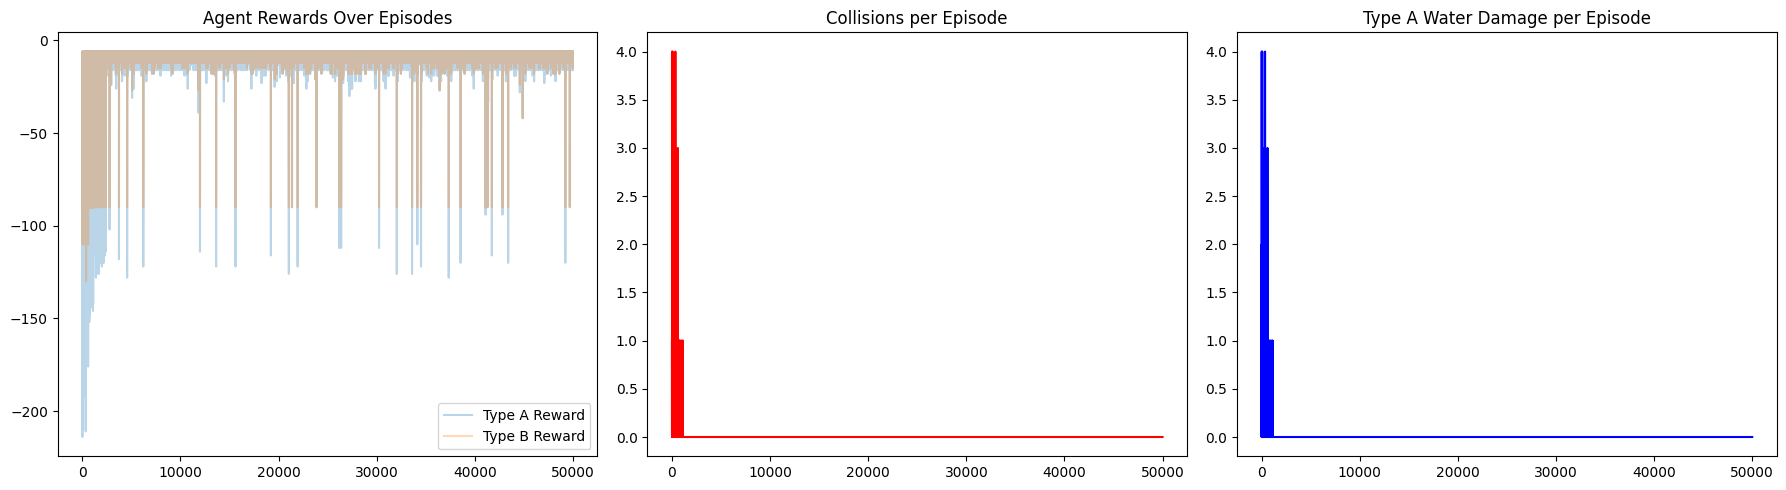

Phase 2 Part 2 Complete!


In [5]:
print("Starting Multi-Agent Training...")
env = MultiAgentEnv()
agent_a = QAgent(MultiAgentConstants.GRID_SIZE)
agent_b = QAgent(MultiAgentConstants.GRID_SIZE)
history = train_multi_agent(env, agent_a, agent_b)

print("Training Complete. Plotting results...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot([h['a'] for h in history], alpha=0.3, label='Type A Reward')
axes[0].plot([h['b'] for h in history], alpha=0.3, label='Type B Reward')
axes[0].set_title('Agent Rewards Over Episodes')
axes[0].legend()

axes[1].plot([h['collisions'] for h in history], color='red')
axes[1].set_title('Collisions per Episode')

axes[2].plot([h['water_dmg'] for h in history], color='blue')
axes[2].set_title('Type A Water Damage per Episode')

plt.tight_layout()
plt.show()
print("Phase 2 Part 2 Complete!")